# Solving the 1D Poisson problem

Authors: Max Schröder, Julian Roth (2021)

In [ ]:
import numpy as np
from scipy.sparse import dok_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

In [ ]:
# quadrature points and weights in 1D
quad = simpson = [(0.0, 1 / 6), (0.5, 4 / 6), (1.0, 1 / 6)]  # simpson rule

In [ ]:
# basis functions in 1D
class Phi0:
    # function evaluation
    def eval(self, x):
        return 1 - x

    # derivative
    def nabla(self, x):
        return -1


class Phi1:
    # function evaluation
    def eval(self, x):
        return x

    # derivative
    def nabla(self, x):
        return 1

In [ ]:
# linear basis functions in 1D
basis_function = {0: Phi0(), 1: Phi1()}

In [ ]:
class Cell:
    def __init__(self, left, right):
        self.dofs = [left, right]

    def quadrature_point(self, x):
        # starting point + translation to the right
        point = self.dofs[0] + x * (self.dofs[1] - self.dofs[0])
        return point.x

In [ ]:
class DoF:
    def __init__(self, x, ind=-1):
        self.x = x
        self.ind = ind

    def __add__(self, other):
        return DoF(self.x + other.x)

    def __sub__(self, other):
        return DoF(self.x - other.x)

    def __rmul__(self, other):
        assert isinstance(
            other, (int, float)
        ), "Multiplication only defined for scalar values"
        return DoF(other * self.x)

In [ ]:
class Mesh:
    def __init__(self, x_min=0.0, x_max=1.0, step_size=0.5):
        self.x_min, self.x_max = x_min, x_max
        self.h = step_size
        self.dofs, self.cells = [], []

    def decompose(self):
        # create mesh and transform it into a list of x and y coordinates
        self.x_range = np.arange(self.x_min, self.x_max, self.h)
        self.x_range = np.append(self.x_range, [self.x_max])
        self.x_num = len(self.x_range)

        # create DoFs
        for i, x in enumerate(self.x_range):
            self.dofs.append(DoF(x, ind=i))

        # create cells
        for i, dof in enumerate(self.dofs):
            if dof.x != self.x_max:
                self.cells.append(Cell(dof, self.dofs[i + 1]))

    def plot_solution(self, solution):
        plt.plot(self.x_range, solution)
        plt.show()

In [ ]:
class PoissonProblem:
    def __init__(self, mesh, f):
        self.mesh = mesh
        self.f = f

    def assemble_system(self):
        # system matrix
        A = dok_matrix((len(self.mesh.dofs), len(self.mesh.dofs)), dtype=np.float32)
        # system right hand side
        F = np.zeros(len(self.mesh.dofs), dtype=np.float32)

        for cell in self.mesh.cells:
            for x, quad_weight in quad:
                for j, dof_j in enumerate(cell.dofs):
                    # assemble rhs
                    F[dof_j.ind] += (
                        quad_weight
                        * self.f(cell.quadrature_point(x))
                        * basis_function[j].eval(x)
                        * self.mesh.h
                    )
                    for i, dof_i in enumerate(cell.dofs):
                        # assemble matrix
                        A[dof_i.ind, dof_j.ind] += (
                            quad_weight
                            * basis_function[i].nabla(x)
                            * basis_function[j].nabla(x)
                            * (1 / self.mesh.h)
                        )

        # apply homogeneous Dirichlet boundary conditions
        for dof in self.mesh.dofs:
            if dof.x in [self.mesh.x_min, self.mesh.x_max]:
                _, nonzero_columns = A[dof.ind, :].nonzero()
                for j in nonzero_columns:
                    A[dof.ind, j] = 0.0
                A[dof.ind, dof.ind] = 1.0
                F[dof.ind] = 0.0

        return A.tocsr(), F

In [ ]:
def example():
    ###############
    # DESCRIPTION #
    ###############
    # Clothesline problem:
    # Solving the Poisson problem on Ω = (0,1).
    # PDE:  - Δ u = -1          in Ω
    # BC:   u(x,y) = 0          on ∂Ω
    # Analytical solution: u = 0.5 * x * (1 - x)

    ##############
    # PARAMETERS #
    ##############
    # right-hand side
    f = lambda x: -1.0

    ########
    # CODE #
    ########
    mesh = Mesh(step_size=0.1)
    mesh.decompose()

    pde = PoissonProblem(mesh=mesh, f=f)
    A, F = pde.assemble_system()
    solution = spsolve(A, F)  # U = A^{-1}F

    mesh.plot_solution(solution)

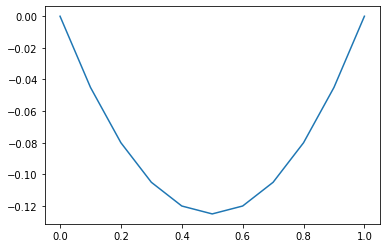

In [ ]:
# Run the example
example()